In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from io import StringIO

# Load Open-Meteo file from S3
bucket = "gridsense-ai-data-team1"
s3 = boto3.client("s3")

obj = s3.get_object(Bucket=bucket, Key="openmeteo_weather_2022_2024.csv")
df = pd.read_csv(obj["Body"])

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nHead:")
print(df.head())

Shape: (26304, 5)

Columns: ['time', 'temperature_2m', 'wind_speed_10m', 'cloud_cover', 'shortwave_radiation']

Head:
               time  temperature_2m  wind_speed_10m  cloud_cover  \
0  2022-01-01T00:00             4.2            22.8          100   
1  2022-01-01T01:00             3.9            23.9          100   
2  2022-01-01T02:00             3.5            27.3          100   
3  2022-01-01T03:00             3.2            26.7          100   
4  2022-01-01T04:00             3.0            27.2          100   

   shortwave_radiation  
0                  0.0  
1                  0.0  
2                  0.0  
3                  0.0  
4                  0.0  


In [2]:
# Data types, missing values, and date conversion
df['time'] = pd.to_datetime(df['time'])

print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDate Range:")
print("Start:", df['time'].min())
print("End:", df['time'].max())
print("\nSummary Statistics:")
print(df.describe())

Data Types:
time                   datetime64[ns]
temperature_2m                float64
wind_speed_10m                float64
cloud_cover                     int64
shortwave_radiation           float64
dtype: object

Missing Values:
time                   0
temperature_2m         0
wind_speed_10m         0
cloud_cover            0
shortwave_radiation    0
dtype: int64

Date Range:
Start: 2022-01-01 00:00:00
End: 2024-12-31 23:00:00

Summary Statistics:
                      time  temperature_2m  wind_speed_10m   cloud_cover  \
count                26304    26304.000000    26304.000000  26304.000000   
mean   2023-07-02 23:30:00       10.934557       17.378536     58.753574   
min    2022-01-01 00:00:00      -24.900000        0.000000      0.000000   
25%    2022-10-01 23:45:00        2.500000       11.700000      5.000000   
50%    2023-07-02 23:30:00       11.400000       16.500000     84.000000   
75%    2024-04-01 23:15:00       19.800000       22.300000    100.000000   
max    2024

In [4]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Check for outliers using IQR
print("\nOutlier Detection:")
for col in ['temperature_2m', 'wind_speed_10m', 'cloud_cover', 'shortwave_radiation']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"  {col}: {outliers} outliers (lower bound: {lower:.2f}, upper bound: {upper:.2f})")

Duplicate rows: 0

Outlier Detection:
  temperature_2m: 10 outliers (lower bound: -23.45, upper bound: 45.75)
  wind_speed_10m: 269 outliers (lower bound: -4.20, upper bound: 38.20)
  cloud_cover: 0 outliers (lower bound: -137.50, upper bound: 242.50)
  shortwave_radiation: 1296 outliers (lower bound: -451.50, upper bound: 752.50)


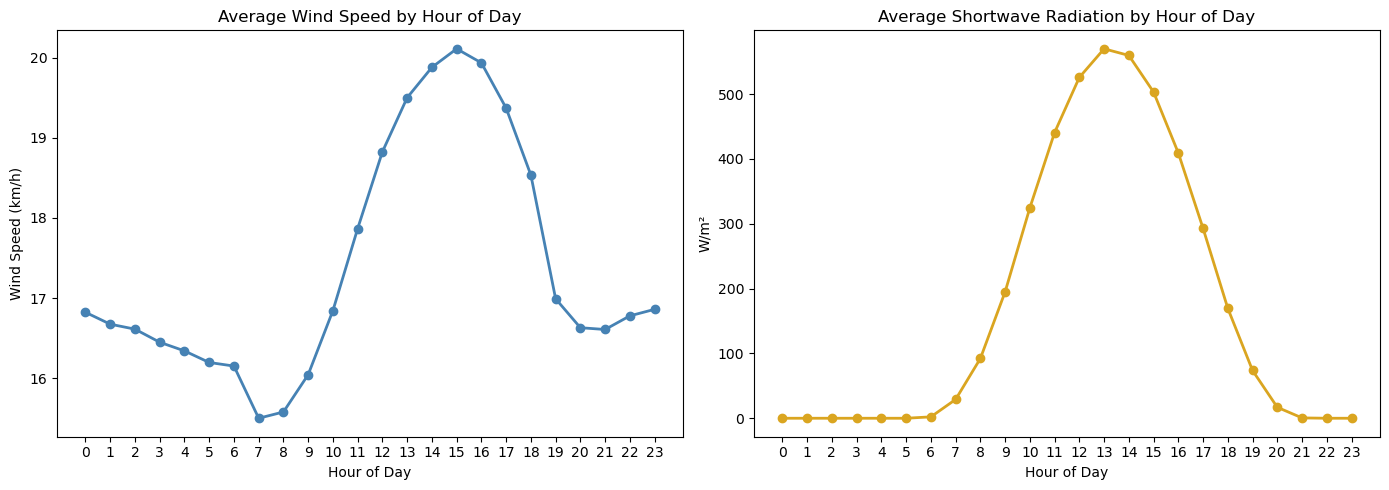

Plot saved.


In [6]:
# Average wind speed and shortwave radiation by hour of day
df['hour'] = df['time'].dt.hour

hourly_avg = df.groupby('hour')[['wind_speed_10m', 'shortwave_radiation']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hourly_avg.index, hourly_avg['wind_speed_10m'], 
             color='steelblue', marker='o', linewidth=2)
axes[0].set_title('Average Wind Speed by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Wind Speed (km/h)')
axes[0].set_xticks(range(0, 24))

axes[1].plot(hourly_avg.index, hourly_avg['shortwave_radiation'], 
             color='goldenrod', marker='o', linewidth=2)
axes[1].set_title('Average Shortwave Radiation by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('W/m²')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('openmeteo_hourly_patterns.png')
plt.show()
print("Plot saved.")

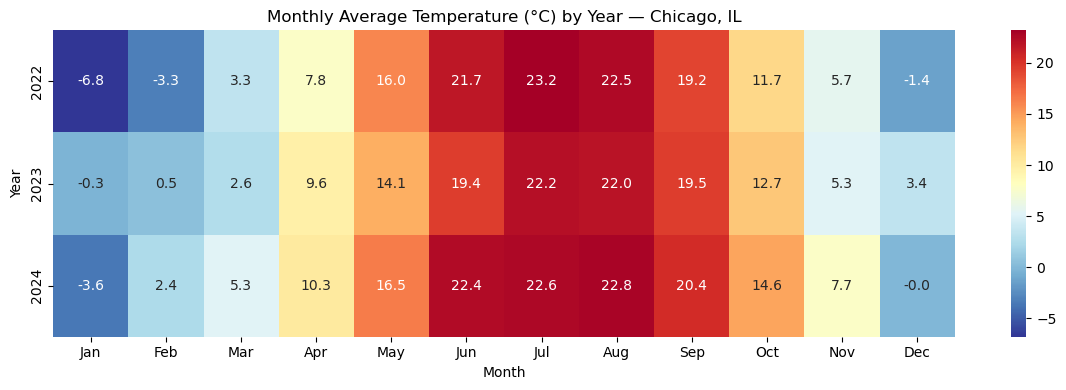

Plot saved.


In [5]:
# Monthly average temperature heatmap
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month

monthly_temp = df.groupby(['year', 'month'])['temperature_2m'].mean().unstack()

plt.figure(figsize=(12, 4))
sns.heatmap(monthly_temp, annot=True, fmt='.1f', cmap='RdYlBu_r',
            xticklabels=['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'],
            yticklabels=['2022','2023','2024'])
plt.title('Monthly Average Temperature (°C) by Year — Chicago, IL')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.savefig('openmeteo_temp_heatmap.png')
plt.show()
print("Plot saved.")

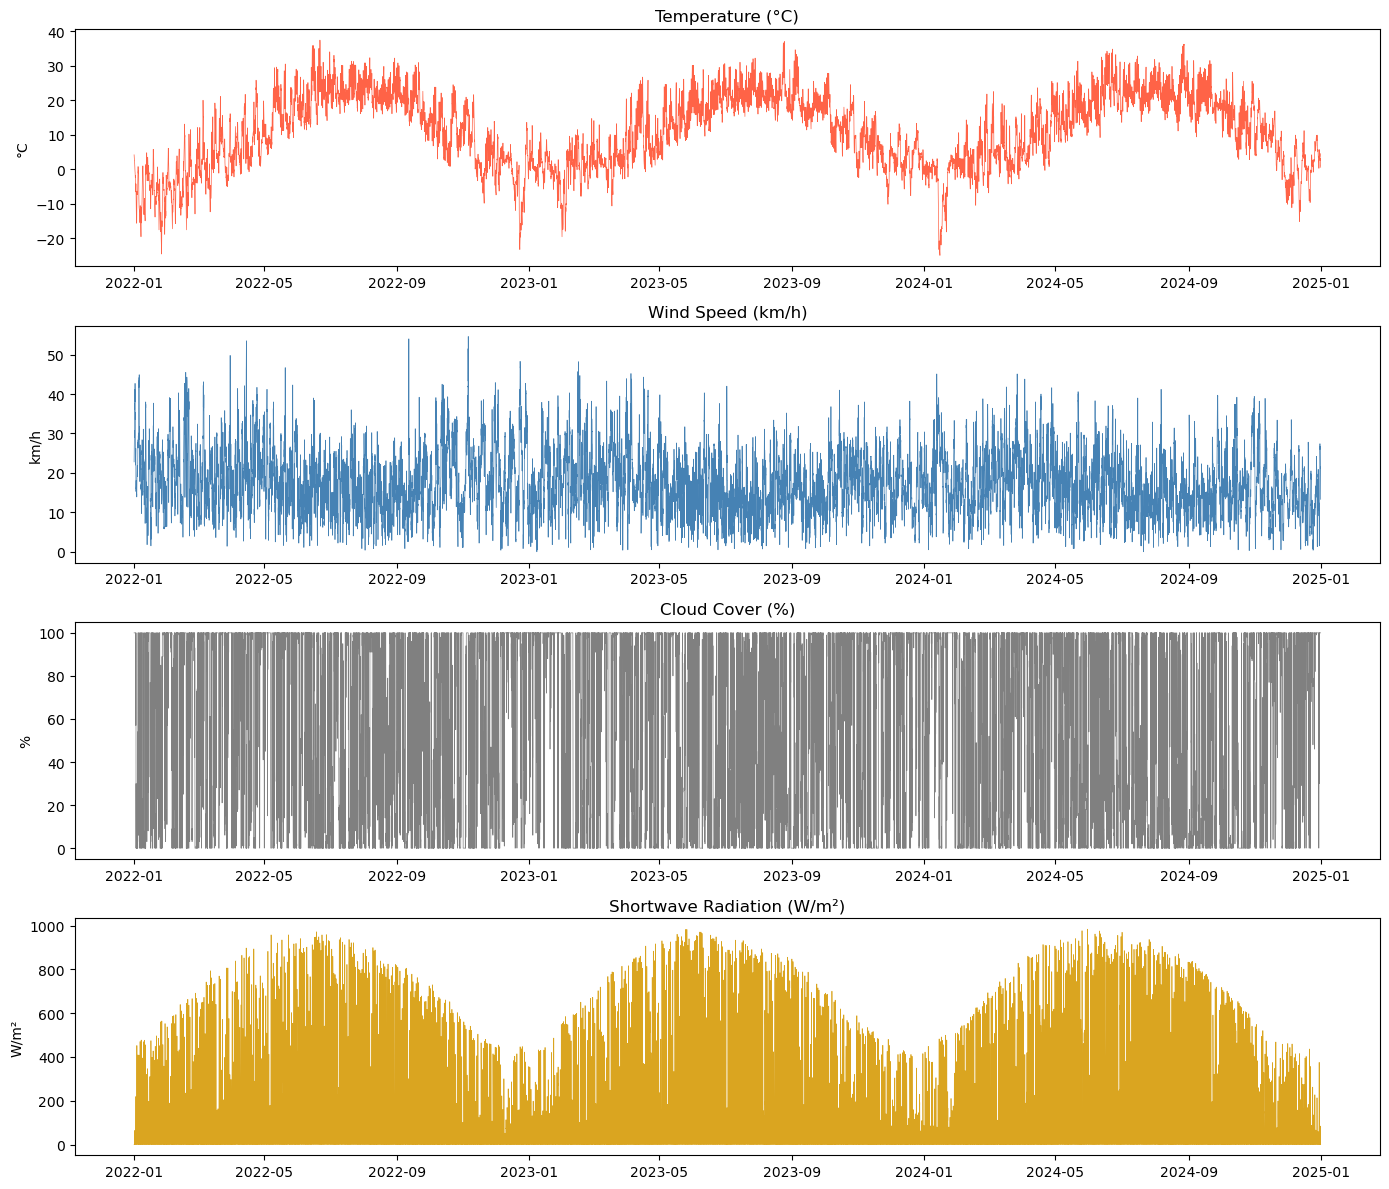

Plot saved.


In [3]:
# Plot all four weather variables over time
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

axes[0].plot(df['time'], df['temperature_2m'], linewidth=0.5, color='tomato')
axes[0].set_title('Temperature (°C)')
axes[0].set_ylabel('°C')

axes[1].plot(df['time'], df['wind_speed_10m'], linewidth=0.5, color='steelblue')
axes[1].set_title('Wind Speed (km/h)')
axes[1].set_ylabel('km/h')

axes[2].plot(df['time'], df['cloud_cover'], linewidth=0.5, color='gray')
axes[2].set_title('Cloud Cover (%)')
axes[2].set_ylabel('%')

axes[3].plot(df['time'], df['shortwave_radiation'], linewidth=0.5, color='goldenrod')
axes[3].set_title('Shortwave Radiation (W/m²)')
axes[3].set_ylabel('W/m²')

plt.tight_layout()
plt.savefig('openmeteo_variables.png')
plt.show()
print("Plot saved.")

## Open-Meteo Data Exploration Summary

**Dataset:** Open-Meteo Historical Weather API (Chicago, IL — Central MISO Region)  
**Shape:** 26,304 rows × 5 columns  
**Date Range:** January 1, 2022 to December 31, 2024  

### Key Findings
- Zero null values and zero duplicate rows — complete hourly records
- 26,304 rows matches ERCOT EIA dataset exactly — ready for merging
- Temperature ranges from -24.9°C to 37.4°C capturing seasonal extremes
- Shortwave radiation shows strong seasonal pattern — peaks in summer, near zero in winter nights
- Cloud cover is highly variable, frequently at 0% or 100%
- Monthly temperature heatmap shows July and August are consistently the hottest months across all three years
- 2022 had a notably colder January (-6.8°C) compared to 2023 and 2024 — important for model generalization
- Shortwave radiation peaks at hour 13-14 — solar generation strongest in early afternoon
- Wind speed is lowest at hours 7-8 and peaks at hour 15 — afternoon winds slightly offset solar peak
- Solar generation drops off after hour 14 while wind picks up through hour 15 — this supply shift is a critical signal for grid stress prediction
- Wind speed outliers (269 records above 38.2 km/h) represent real weather extremes and were retained

### Data Quality Concerns
- Time column loaded as object dtype — converted to datetime
- Wind speed has 269 outliers and shortwave radiation has 1,296 outliers — these are valid extreme weather events and should be retained for model training
- Chicago coordinates used (41.8781, -87.6298) — represents MISO region, not ERCOT

### Bias Considerations
- **Geographic bias:** Weather data is from Chicago, not Texas — temperature and solar patterns may not perfectly reflect ERCOT grid conditions
- **Seasonal bias:** Dataset spans 3 full years capturing all seasons equally — low seasonal bias risk
- **Reporting bias:** No known revision policy for Open-Meteo historical data — assumed to be stable